# Eigenvalue Decomposition (EVD) — From First Principles

> **Quant interview note:** Eigenvalues and eigenvectors are *everywhere* in quant interviews. PCA (the #1 dimensionality-reduction question), covariance-matrix analysis, portfolio risk decomposition, positive-definiteness checks for valid covariance matrices, and "what does this matrix *do* geometrically?" all reduce to EVD. If you understand this notebook deeply, you've covered a huge chunk of the linear-algebra surface area that desks like to probe.

This notebook builds eigenvalue decomposition from scratch. We'll go in this order:

1. **The core idea** — a matrix is a *transformation*; eigenvectors are the directions it doesn't rotate.
2. **Computing them** — characteristic polynomial, by hand on a 2×2.
3. **Diagonalization** — $A = P\Lambda P^{-1}$ and why it's so useful (matrix powers!).
4. **Symmetric matrices** — the spectral theorem: the most beautiful structure in linear algebra.
5. **Quadratic forms** — the geometry of $\mathbf{x}^\top A \mathbf{x}$, ellipses, and definiteness.
6. **Eigenvectors optimize quadratic forms** — the Rayleigh quotient.
7. **Standardizing & whitening data** — turning correlated blobs into clean spheres.
8. **The power method** — how you'd actually find the top eigenvector with just matrix-vector products.
9. **Deflation** — peeling off eigenvectors one at a time.

Everything is implemented in numpy and visualized.

---

## 0 · Setup

Standard imports and a consistent plotting style. We'll lean on a fixed color palette throughout: `steelblue`, `tomato`, `mediumseagreen`, `darkorange`, `navy`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, FancyArrow

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "font.family":      "sans-serif",
})

PALETTE = ["steelblue", "tomato", "mediumseagreen", "darkorange", "navy"]
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)
print("Setup complete.")

Setup complete.


---
## 1 · A matrix is a transformation; eigenvectors are its special directions

Forget formulas for a second. The cleanest way to *feel* eigenvectors (very 3Blue1Brown) is this:

> **Key insight:** A square matrix $A$ is a function that takes a vector $\mathbf{x}$ and moves it to a new vector $A\mathbf{x}$. For *most* input vectors, the output points in a **different direction** — the matrix rotates them. But a few special directions get **only stretched or squished, never rotated**. Those are the **eigenvectors**, and the stretch factor is the **eigenvalue**.

Formally, $\mathbf{v} \neq \mathbf{0}$ is an **eigenvector** of $A$ with **eigenvalue** $\lambda$ if

$$A\mathbf{v} = \lambda \mathbf{v}.$$

Read it as: *"applying the matrix $A$ to $\mathbf{v}$ does the same thing as just scaling $\mathbf{v}$ by the number $\lambda$."* The matrix-times-vector (a complicated operation) collapses to a scalar-times-vector (the simplest possible operation) — but only along these magic directions.

| Symbol | Meaning |
|--------|---------|
| $A$ | An $n\times n$ square matrix — the transformation |
| $\mathbf{v}$ | An eigenvector — a direction left un-rotated by $A$ |
| $\lambda$ | The eigenvalue — how much $\mathbf{v}$ is stretched ($\lambda>1$) or squished ($0<\lambda<1$); $\lambda<0$ flips it |

Let's *see* it. We take one matrix, apply it to a circle of unit vectors, and watch which arrows stay on their original line.

In [2]:
# A simple shear-ish matrix
A = np.array([[2.0, 1.0],
              [1.0, 2.0]])

# numpy gives us the answer; we'll derive it by hand next section.
eigvals, eigvecs = np.linalg.eigh(A)   # eigh: symmetric solver, returns ascending
print("eigenvalues:", eigvals)
print("eigenvectors (columns):\n", eigvecs)

# Sanity check the definition A v = lambda v for each pair
for i in range(2):
    v = eigvecs[:, i]
    print(f"\nlambda={eigvals[i]:.3f}")
    print("  A v      =", A @ v)
    print("  lambda v =", eigvals[i] * v)

eigenvalues: [1. 3.]
eigenvectors (columns):
 [[-0.7071  0.7071]
 [ 0.7071  0.7071]]

lambda=1.000
  A v      = [-0.7071  0.7071]
  lambda v = [-0.7071  0.7071]

lambda=3.000
  A v      = [2.1213 2.1213]
  lambda v = [2.1213 2.1213]


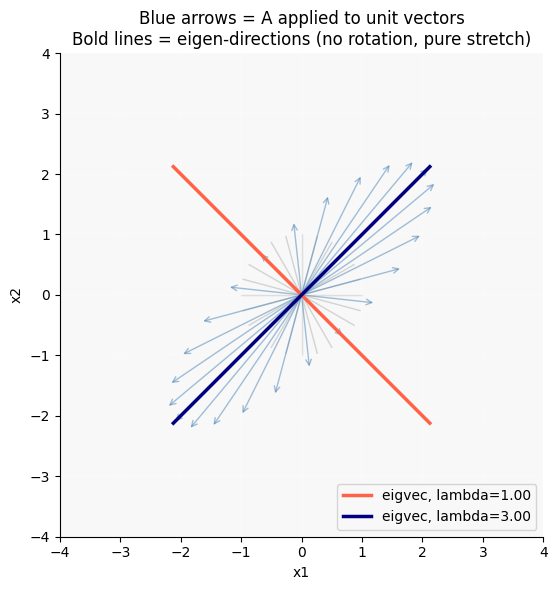

In [3]:
# Visualize: take many unit vectors, draw x (light) and A@x (dark).
# Vectors lying on an eigen-direction map to a parallel arrow (no rotation).
thetas = np.linspace(0, 2*np.pi, 24, endpoint=False)
fig, ax = plt.subplots(figsize=(6, 6))

for t in thetas:
    x = np.array([np.cos(t), np.sin(t)])
    Ax = A @ x
    ax.plot([0, x[0]], [0, x[1]], color="lightgray", lw=1, zorder=1)
    ax.annotate("", xy=Ax, xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color="steelblue", alpha=0.5, lw=1), zorder=2)

# Draw the eigen-directions as bold lines
for i, c in zip(range(2), ["tomato", "navy"]):
    v = eigvecs[:, i]
    ax.plot([-3*v[0], 3*v[0]], [-3*v[1], 3*v[1]], color=c, lw=2.5,
            label=f"eigvec, lambda={eigvals[i]:.2f}", zorder=3)

ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.set_aspect("equal")
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title("Blue arrows = A applied to unit vectors\nBold lines = eigen-directions (no rotation, pure stretch)")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Notice the blue arrows along the bold lines point *straight out along the same line* — they're only lengthened. Off those lines, the arrows swing toward the dominant eigen-direction. That swinging is exactly what the **power method** (Section 8) will exploit.

---
## 2 · Computing eigenvalues: the characteristic polynomial

How did numpy find those numbers? Start from the definition and do algebra:

$$A\mathbf{v} = \lambda\mathbf{v} \;\;\Longrightarrow\;\; A\mathbf{v} - \lambda\mathbf{v} = \mathbf{0} \;\;\Longrightarrow\;\; (A - \lambda I)\mathbf{v} = \mathbf{0}.$$

Here $I$ is the identity matrix, and we inserted it so we can factor out $\mathbf{v}$ (you can't subtract a scalar $\lambda$ from a matrix $A$ directly — $\lambda I$ is the matrix version of "$\lambda$").

Now the crucial logic. We need a **nonzero** $\mathbf{v}$ that the matrix $(A-\lambda I)$ sends to zero. A matrix sends a nonzero vector to zero **only if it is singular** (non-invertible) — an invertible matrix only kills the zero vector. And a matrix is singular exactly when its **determinant is zero**:

$$\boxed{\;\det(A - \lambda I) = 0\;}$$

This is the **characteristic equation**. Expanding the determinant gives a degree-$n$ polynomial in $\lambda$ — the **characteristic polynomial** — whose roots are the eigenvalues.

> **Key insight:** "Eigenvalues are the values of $\lambda$ that make $A-\lambda I$ collapse a dimension (become singular)." That collapsed direction is the eigenvector.

### Worked 2×2 by hand

For our $A=\begin{pmatrix}2&1\\1&2\end{pmatrix}$:

$$A-\lambda I=\begin{pmatrix}2-\lambda & 1\\ 1 & 2-\lambda\end{pmatrix},\qquad \det = (2-\lambda)^2 - 1.$$

Set to zero: $(2-\lambda)^2 = 1 \Rightarrow 2-\lambda = \pm 1 \Rightarrow \lambda = 1 \text{ or } 3.$ ✓ (matches numpy).

For a general 2×2 there's a slick shortcut interviewers love:

$$\lambda^2 - \underbrace{\operatorname{tr}(A)}_{\text{sum of diag}}\lambda + \underbrace{\det(A)}_{\text{}} = 0,$$

because **trace = sum of eigenvalues** and **determinant = product of eigenvalues**. Memorize this — it's a classic quant quick-fire question.

In [4]:
# Verify the trace / determinant identities (they hold for ANY square matrix)
M = np.array([[4.0, 1.0],
              [2.0, 3.0]])
vals = np.linalg.eigvals(M)
print("eigenvalues      :", vals)
print("sum of eigvals   :", vals.sum(),     " vs trace(M) =", np.trace(M))
print("prod of eigvals  :", np.prod(vals),  " vs det(M)   =", np.linalg.det(M))

eigenvalues      : [5. 2.]
sum of eigvals   : 7.0  vs trace(M) = 7.0
prod of eigvals  : 10.0  vs det(M)   = 10.000000000000002


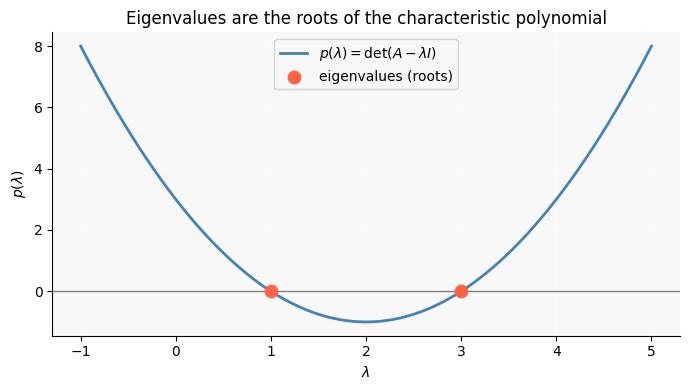

In [5]:
# Build the characteristic polynomial p(lambda)=det(A - lambda I) and plot it.
A = np.array([[2.0, 1.0], [1.0, 2.0]])
lam = np.linspace(-1, 5, 400)
p = np.array([np.linalg.det(A - L*np.eye(2)) for L in lam])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lam, p, color="steelblue", lw=2, label=r"$p(\lambda)=\det(A-\lambda I)$")
ax.axhline(0, color="gray", lw=1)
roots = np.linalg.eigvalsh(A)
ax.scatter(roots, [0, 0], color="tomato", zorder=5, s=80, label="eigenvalues (roots)")
ax.set_xlabel(r"$\lambda$"); ax.set_ylabel(r"$p(\lambda)$")
ax.set_title("Eigenvalues are the roots of the characteristic polynomial")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 3 · Diagonalization: $A = P\Lambda P^{-1}$

If an $n\times n$ matrix has $n$ independent eigenvectors, stack them as the columns of $P$ and put the eigenvalues on the diagonal of $\Lambda$. Then:

$$\boxed{\,A = P\,\Lambda\,P^{-1}\,}\qquad \Lambda=\operatorname{diag}(\lambda_1,\dots,\lambda_n),\quad P=[\,\mathbf{v}_1\;\cdots\;\mathbf{v}_n\,].$$

**Why this is true (and intuitive):** read $A = P\Lambda P^{-1}$ right-to-left as a three-step recipe for what $A$ does to any vector $\mathbf{x}$:

1. $P^{-1}\mathbf{x}$ — **change coordinates** into the eigenvector basis ("how much of each eigenvector are you?").
2. $\Lambda(\cdot)$ — **scale** each eigen-coordinate by its eigenvalue (the easy part — just multiply numbers).
3. $P(\cdot)$ — **change back** to the original coordinates.

> **Key insight:** In its *own* eigenvector coordinate system, a matrix is just independent stretching along each axis. Diagonalization is the act of finding the coordinate system where the matrix becomes "boring" (diagonal).

### The killer application: matrix powers

Computing $A^{10}$ by repeated multiplication is expensive and opaque. But

$$A^k = (P\Lambda P^{-1})^k = P\,\Lambda^k\,P^{-1},$$

because all the inner $P^{-1}P$ pairs cancel. And $\Lambda^k$ is trivial — just raise each diagonal entry to the $k$. This is the backbone of **Markov chains, PageRank, and discrete dynamical systems** — all common quant topics. The long-run behavior is dominated by the largest $|\lambda|$.

In [6]:
A = np.array([[2.0, 1.0], [1.0, 2.0]])
vals, P = np.linalg.eigh(A)
Lam = np.diag(vals)

# Reconstruct A from its pieces
A_reconstructed = P @ Lam @ np.linalg.inv(P)
print("Reconstruction error |A - P Lam P^-1| =", np.linalg.norm(A - A_reconstructed))

# A^5 the slow way vs the eigen way
k = 5
A_slow = np.linalg.matrix_power(A, k)
A_eig  = P @ np.diag(vals**k) @ np.linalg.inv(P)
print(f"\nA^{k} via matrix_power:\n", A_slow)
print(f"max diff vs P Lam^{k} P^-1:", np.abs(A_slow - A_eig).max())

Reconstruction error |A - P Lam P^-1| = 0.0

A^5 via matrix_power:
 [[122. 121.]
 [121. 122.]]
max diff vs P Lam^5 P^-1: 0.0


---
## 4 · The special structure of symmetric matrices (the Spectral Theorem)

This is the single most important case for quant work, because **every covariance matrix and every correlation matrix is symmetric**. A matrix is symmetric if $A = A^\top$.

Symmetric matrices are blessed with gorgeous structure — the **Spectral Theorem**:

> **Spectral Theorem.** If $A$ is real and symmetric, then:
> 1. All its eigenvalues are **real** (no scary complex numbers).
> 2. Its eigenvectors can be chosen **orthonormal** — mutually perpendicular and unit length.
>
> So $A = Q\Lambda Q^\top$ where $Q$ is an **orthogonal** matrix ($Q^\top Q = I$, i.e. $Q^{-1}=Q^\top$).

Notice $P^{-1}$ became $Q^\top$ — inverting an orthogonal matrix is free, you just transpose it. Geometrically:

> **Key insight:** A symmetric matrix acts as: **rotate to the eigen-axes ($Q^\top$), stretch along them ($\Lambda$), rotate back ($Q$)**. No shearing, no skewing — pure stretch along perpendicular axes. That's why symmetric matrices map circles to *axis-aligned-in-the-rotated-frame* ellipses.

The `np.linalg.eigh` function (the "h" is for *Hermitian*/symmetric) exploits this — it's faster and more numerically stable than the general `eig`. **Always use `eigh` for covariance matrices.**

Let's verify orthogonality of the eigenvectors on a random symmetric matrix.

In [7]:
# Make a random SYMMETRIC matrix: B + B^T is always symmetric
B = rng.standard_normal((4, 4))
S = B + B.T
print("Is S symmetric? ", np.allclose(S, S.T))

vals, Q = np.linalg.eigh(S)
print("\neigenvalues (all real):", vals)
print("\nQ^T Q (should be identity -> eigenvectors orthonormal):\n", Q.T @ Q)
print("\nReconstruct S = Q Lam Q^T, error =",
      np.linalg.norm(S - Q @ np.diag(vals) @ Q.T))

Is S symmetric?  True

eigenvalues (all real): [-3.4957 -0.9039  0.2303  2.4328]

Q^T Q (should be identity -> eigenvectors orthonormal):
 [[ 1. -0. -0.  0.]
 [-0.  1.  0. -0.]
 [-0.  0.  1.  0.]
 [ 0. -0.  0.  1.]]

Reconstruct S = Q Lam Q^T, error = 2.8789971694427464e-15


---
## 5 · The geometry of quadratic forms

A **quadratic form** is a function that takes a vector and returns a single number using a symmetric matrix $A$:

$$q(\mathbf{x}) = \mathbf{x}^\top A\,\mathbf{x} = \sum_{i,j} A_{ij}\,x_i x_j.$$

Think of it as the multidimensional generalization of $a x^2$. In 2D it expands to $A_{11}x_1^2 + 2A_{12}x_1x_2 + A_{22}x_2^2$. The level sets $\{\mathbf{x}: q(\mathbf{x})=c\}$ are **ellipses** (if $A$ is positive definite), and **eigenvectors are the axes of those ellipses**:

- Each eigenvector $\mathbf{v}_i$ points along a **principal axis** of the ellipse.
- The axis **length** is proportional to $1/\sqrt{\lambda_i}$ — *bigger eigenvalue ⇒ steeper bowl ⇒ shorter axis*.

### Definiteness (a constant interview topic)

The signs of the eigenvalues classify the matrix:

| Class | Condition | $q(\mathbf{x})$ shape | Meaning |
|-------|-----------|-----------------------|---------|
| **Positive definite** | all $\lambda_i > 0$ | bowl opening up | $\mathbf{x}^\top A\mathbf{x}>0$ for all $\mathbf{x}\neq 0$ |
| **Positive semidefinite (PSD)** | all $\lambda_i \ge 0$ | bowl, possibly flat directions | $\ge 0$ always |
| **Indefinite** | mixed signs | saddle | can be $+$ or $-$ |
| **Negative definite** | all $\lambda_i < 0$ | dome | $<0$ always |

> **Quant interview note:** "When is a matrix a valid covariance matrix?" Answer: **iff it is symmetric positive semidefinite.** Variances ($\mathbf{w}^\top \Sigma \mathbf{w}$ = variance of portfolio $\mathbf{w}$) can never be negative, which forces $\Sigma$ to be PSD. Checking eigenvalue signs is *the* test. Negative eigenvalues in an empirical covariance matrix (from noisy/insufficient data) is a real and frequently-discussed problem.

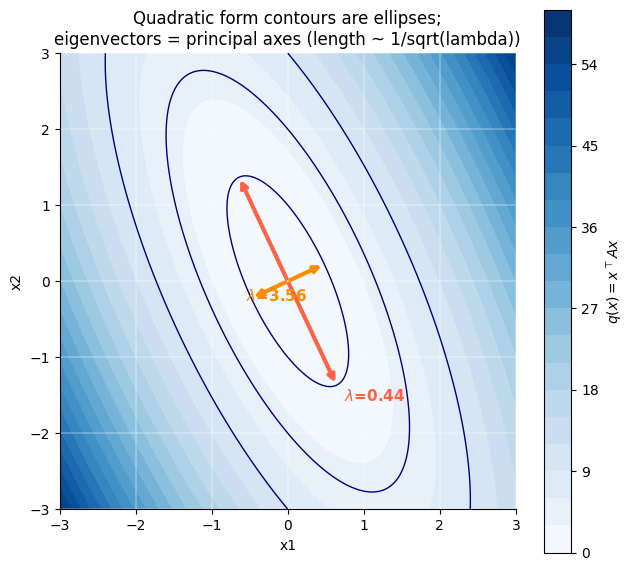

In [8]:
# Visualize the quadratic form x^T A x as filled contours, with eigenvectors as axes.
A = np.array([[3.0, 1.2],
              [1.2, 1.0]])
vals, vecs = np.linalg.eigh(A)

g = np.linspace(-3, 3, 300)
X1, X2 = np.meshgrid(g, g)
# q = A11 x1^2 + 2 A12 x1 x2 + A22 x2^2
Q = A[0,0]*X1**2 + 2*A[0,1]*X1*X2 + A[1,1]*X2**2

fig, ax = plt.subplots(figsize=(6.5, 6))
cf = ax.contourf(X1, X2, Q, levels=20, cmap="Blues")
ax.contour(X1, X2, Q, levels=[1, 4, 9], colors="navy", linewidths=1)
plt.colorbar(cf, ax=ax, label=r"$q(x)=x^\top A x$")

# eigenvectors scaled by 1/sqrt(lambda) -> they reach the q=1 ellipse
for i, c in zip(range(2), ["tomato", "darkorange"]):
    v = vecs[:, i] / np.sqrt(vals[i])
    ax.annotate("", xy=v, xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color=c, lw=3))
    ax.annotate("", xy=-v, xytext=(0,0),
                arrowprops=dict(arrowstyle="->", color=c, lw=3))
    ax.text(*(1.15*v), f"$\\lambda$={vals[i]:.2f}", color=c, fontsize=11, weight="bold")

ax.set_xlim(-3,3); ax.set_ylim(-3,3); ax.set_aspect("equal")
ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title("Quadratic form contours are ellipses;\neigenvectors = principal axes (length ~ 1/sqrt(lambda))")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 6 · Eigenvectors *optimize* quadratic forms (the Rayleigh quotient)

Here's the bridge from algebra to optimization — and the reason PCA works. Ask:

> Among all **unit** vectors $\mathbf{x}$ (so $\|\mathbf{x}\|=1$), which direction makes the quadratic form $\mathbf{x}^\top A\mathbf{x}$ as **large** as possible?

If we didn't constrain the length we could make $\mathbf{x}^\top A\mathbf{x}$ blow up to infinity just by scaling $\mathbf{x}$ — so the unit-length constraint is what makes the question meaningful. The constrained objective is the **Rayleigh quotient**:

$$R(\mathbf{x}) = \frac{\mathbf{x}^\top A\,\mathbf{x}}{\mathbf{x}^\top \mathbf{x}}.$$

(Dividing by $\mathbf{x}^\top\mathbf{x}=\|\mathbf{x}\|^2$ automatically normalizes, so we don't even need to constrain length explicitly.)

**Claim:** $R(\mathbf{x})$ ranges exactly between the smallest and largest eigenvalue,

$$\lambda_{\min} \le R(\mathbf{x}) \le \lambda_{\max},$$

with the **max achieved at the top eigenvector** and the **min at the bottom one**.

### Derivation with Lagrange multipliers (worth knowing cold)

Maximize $\mathbf{x}^\top A\mathbf{x}$ subject to $\mathbf{x}^\top\mathbf{x}=1$. The Lagrangian is

$$\mathcal{L}(\mathbf{x},\lambda) = \mathbf{x}^\top A\mathbf{x} - \lambda(\mathbf{x}^\top\mathbf{x} - 1).$$

Take the gradient w.r.t. $\mathbf{x}$ and set it to zero. Using $\nabla_\mathbf{x}(\mathbf{x}^\top A\mathbf{x}) = 2A\mathbf{x}$ (valid since $A$ is symmetric) and $\nabla_\mathbf{x}(\mathbf{x}^\top\mathbf{x}) = 2\mathbf{x}$:

$$\nabla_\mathbf{x}\mathcal{L} = 2A\mathbf{x} - 2\lambda\mathbf{x} = \mathbf{0} \;\;\Longrightarrow\;\; A\mathbf{x} = \lambda\mathbf{x}.$$

> **Key insight:** The optimality condition for "best direction of a quadratic form" is *literally the eigenvector equation*. The Lagrange multiplier $\lambda$ turns out to be the eigenvalue, and at the optimum the objective value equals $\lambda$. So **the steepest direction is the top eigenvector, and its eigenvalue is the maximum value.** This is exactly why PCA's first principal component = top eigenvector of the covariance matrix.

Let's confirm numerically by brute force over all directions in 2D.

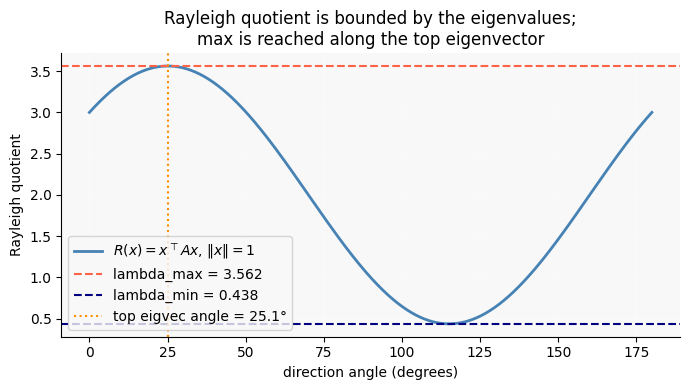

Empirical max R: 3.562027574414307  at angle 25.250501002004007
lambda_max     : 3.562049935181331


In [9]:
A = np.array([[3.0, 1.2],
              [1.2, 1.0]])
vals, vecs = np.linalg.eigh(A)   # ascending

thetas = np.linspace(0, np.pi, 500)   # half circle covers all directions (R is even)
R = []
for t in thetas:
    x = np.array([np.cos(t), np.sin(t)])
    R.append(x @ A @ x)              # denominator is 1 for unit x
R = np.array(R)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.degrees(thetas), R, color="steelblue", lw=2, label=r"$R(x)=x^\top A x$, $\|x\|=1$")
ax.axhline(vals.max(), color="tomato",  ls="--", label=f"lambda_max = {vals.max():.3f}")
ax.axhline(vals.min(), color="navy",    ls="--", label=f"lambda_min = {vals.min():.3f}")
# angle of top eigenvector
ang_top = np.degrees(np.arctan2(vecs[1,1], vecs[0,1])) % 180
ax.axvline(ang_top, color="darkorange", ls=":", label=f"top eigvec angle = {ang_top:.1f}°")
ax.set_xlabel("direction angle (degrees)"); ax.set_ylabel("Rayleigh quotient")
ax.set_title("Rayleigh quotient is bounded by the eigenvalues;\nmax is reached along the top eigenvector")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Empirical max R:", R.max(), " at angle", np.degrees(thetas[R.argmax()]))
print("lambda_max     :", vals.max())

---
## 7 · Standardizing and whitening data

Now the practical payoff. Real financial data comes as correlated, differently-scaled blobs. Two cleanup operations:

- **Standardizing** (z-scoring): subtract the mean, divide by the std *per feature*. Centers the cloud and makes each axis unit-variance — but leaves the **correlation** (the tilt) intact.
- **Whitening**: a stronger transform that also **removes correlation**, turning the data cloud into a perfectly round, unit-variance sphere with **identity covariance**. This is where eigenvectors come in.

### The whitening recipe

Let the data have covariance $\Sigma$. Eigendecompose it (symmetric ⇒ spectral theorem):

$$\Sigma = Q\Lambda Q^\top.$$

Define the whitened data (after centering $\mathbf{x}\to\mathbf{x}-\boldsymbol\mu$):

$$\mathbf{z} = \Lambda^{-1/2}Q^\top(\mathbf{x}-\boldsymbol\mu).$$

Reading right-to-left: **$Q^\top$ rotates** the cloud so its correlation axes line up with the coordinate axes; **$\Lambda^{-1/2}$ rescales** each axis by $1/\sqrt{\lambda_i}$ so every direction has variance 1. The result has covariance $I$.

**Why it works (one line):**
$$\operatorname{Cov}(\mathbf{z}) = \Lambda^{-1/2}Q^\top\,\Sigma\,Q\,\Lambda^{-1/2} = \Lambda^{-1/2}Q^\top (Q\Lambda Q^\top) Q\,\Lambda^{-1/2} = \Lambda^{-1/2}\Lambda\,\Lambda^{-1/2} = I.$$
(The $Q^\top Q = I$ pairs cancel because $Q$ is orthogonal.)

> **Key insight:** $\Lambda^{-1/2}Q^\top$ is exactly the "rotate to eigen-axes, then squish each by its spread" inverse of what a symmetric matrix does. Whitening *undoes* the covariance.

> **Quant interview note:** Whitening = "what PCA does, plus rescaling." The eigenvectors $Q$ are the **principal components** (directions of max variance), and the eigenvalues $\lambda_i$ are the **variance captured** along each. The Mahalanobis distance $\sqrt{(\mathbf{x}-\mu)^\top\Sigma^{-1}(\mathbf{x}-\mu)}$ is just ordinary Euclidean distance *in whitened space* — a fact interviewers love.

In [10]:
# Generate a correlated, anisotropic 2D Gaussian blob
mean = np.array([1.0, -2.0])
true_cov = np.array([[3.0, 1.8],
                     [1.8, 1.5]])
L = np.linalg.cholesky(true_cov)
data = (rng.standard_normal((1000, 2)) @ L.T) + mean
print("empirical mean:", data.mean(0))
print("empirical cov :\n", np.cov(data, rowvar=False))

empirical mean: [ 0.9467 -2.0493]
empirical cov :
 [[3.1299 1.8514]
 [1.8514 1.4999]]


In [11]:
# --- Whitening from scratch ---
mu = data.mean(0)
Xc = data - mu                              # center
Sigma = np.cov(Xc, rowvar=False)            # 2x2 covariance
vals, Q = np.linalg.eigh(Sigma)             # spectral theorem

W = np.diag(1.0/np.sqrt(vals)) @ Q.T        # whitening matrix  Lambda^{-1/2} Q^T
Z = Xc @ W.T                                # apply to each row

print("covariance of whitened data (should be identity):\n", np.cov(Z, rowvar=False))

covariance of whitened data (should be identity):
 [[1. 0.]
 [0. 1.]]


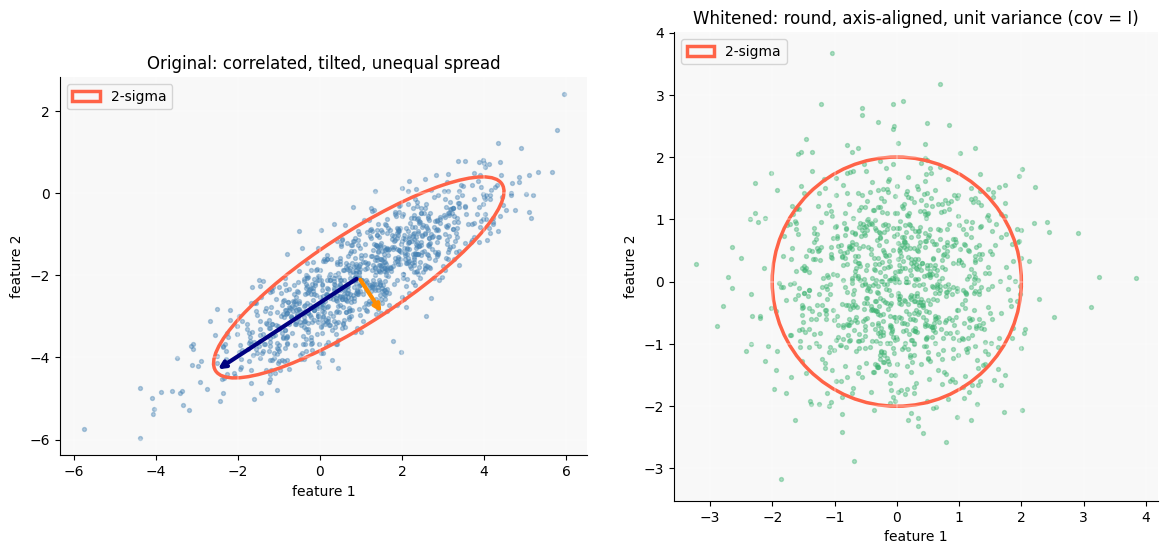

In [12]:
def cov_ellipse(ax, mean, cov, color, label):
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
    width, height = 2*np.sqrt(vals[::-1])*2   # 2-sigma
    e = Ellipse(mean, width, height, angle=angle, fill=False,
                edgecolor=color, lw=2.5, label=label)
    ax.add_patch(e)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].scatter(data[:,0], data[:,1], s=8, color="steelblue", alpha=0.4)
cov_ellipse(axes[0], mu, Sigma, "tomato", "2-sigma")
# draw eigenvectors of Sigma scaled by sqrt(lambda) = std along that axis
for i, c in zip(range(2), ["darkorange", "navy"]):
    v = Q[:, i]*np.sqrt(vals[i])*2
    axes[0].annotate("", xy=mu+v, xytext=mu,
                     arrowprops=dict(arrowstyle="->", color=c, lw=3))
axes[0].set_title("Original: correlated, tilted, unequal spread")
axes[0].set_aspect("equal")

axes[1].scatter(Z[:,0], Z[:,1], s=8, color="mediumseagreen", alpha=0.4)
cov_ellipse(axes[1], [0,0], np.cov(Z, rowvar=False), "tomato", "2-sigma")
axes[1].set_title("Whitened: round, axis-aligned, unit variance (cov = I)")
axes[1].set_aspect("equal")

for ax in axes:
    ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
    ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 8 · The power method — finding the top eigenvector with only matrix-vector products

`np.linalg.eigh` is a black box. How would you find the **dominant** eigenvector (largest $|\lambda|$) yourself, especially for a huge matrix where full decomposition is too expensive? The **power method** is the elegant, classic answer — and a frequent interview "implement this" question.

### The idea

Write any starting vector $\mathbf{x}_0$ in the eigenvector basis: $\mathbf{x}_0 = c_1\mathbf{v}_1 + c_2\mathbf{v}_2 + \dots$ (assume $|\lambda_1| > |\lambda_2| \ge \dots$). Apply $A$ repeatedly. Since $A^k\mathbf{v}_i = \lambda_i^k\mathbf{v}_i$:

$$A^k\mathbf{x}_0 = c_1\lambda_1^k\mathbf{v}_1 + c_2\lambda_2^k\mathbf{v}_2 + \dots = \lambda_1^k\Big(c_1\mathbf{v}_1 + c_2\underbrace{(\lambda_2/\lambda_1)^k}_{\to 0}\mathbf{v}_2 + \dots\Big).$$

Because $|\lambda_2/\lambda_1| < 1$, every term except the first **shrinks to zero** as $k$ grows. The direction of $A^k\mathbf{x}_0$ converges to $\mathbf{v}_1$.

> **Key insight:** Repeatedly applying a matrix amplifies the dominant eigen-direction and starves the rest. (Recall the swinging blue arrows in Section 1 — they were all bending toward the top eigenvector.) Convergence speed depends on the **ratio $|\lambda_2/\lambda_1|$**: a small ratio (well-separated eigenvalues) converges fast.

### Algorithm

1. Start with random $\mathbf{x}$, normalize.
2. Repeat: $\mathbf{x} \leftarrow A\mathbf{x}$, then $\mathbf{x} \leftarrow \mathbf{x}/\|\mathbf{x}\|$ (renormalize so it doesn't blow up / vanish).
3. Estimate eigenvalue via the Rayleigh quotient $\lambda \approx \mathbf{x}^\top A\mathbf{x}$.

In [13]:
def power_method(A, num_iters=100, tol=1e-12, seed=0):
    # Find the dominant eigenvalue/eigenvector. Records a convergence history.
    g = np.random.default_rng(seed)
    x = g.standard_normal(A.shape[0])
    x /= np.linalg.norm(x)
    loss_history = []          # || A x - lambda x || : how close to a true eigenpair
    lam = 0.0
    for _ in range(num_iters):
        Ax = A @ x
        lam = x @ Ax                      # Rayleigh quotient (x is unit norm)
        residual = np.linalg.norm(Ax - lam*x)
        loss_history.append(residual)
        x_new = Ax / np.linalg.norm(Ax)   # renormalize
        if np.linalg.norm(x_new - x) < tol:
            x = x_new
            break
        x = x_new
    return lam, x, loss_history

# Test on a symmetric matrix and compare with the ground truth from eigh
S = np.array([[4.0, 1.0, 0.5],
              [1.0, 3.0, 0.2],
              [0.5, 0.2, 2.0]])
lam_pm, v_pm, loss_history = power_method(S, num_iters=80)

vals_true, vecs_true = np.linalg.eigh(S)
top_true_val = vals_true[-1]
top_true_vec = vecs_true[:, -1]

print("power method eigenvalue:", lam_pm)
print("true top eigenvalue    :", top_true_val)
# sign of eigenvector is arbitrary; align before comparing
if np.dot(v_pm, top_true_vec) < 0: top_true_vec = -top_true_vec
print("\npower method eigenvector:", v_pm)
print("true top eigenvector    :", top_true_vec)
print("\nfinal residual ||Ax - lambda x||:", loss_history[-1])

power method eigenvalue: 4.721570077747948
true top eigenvalue    : 4.72157007774795

power method eigenvector: [0.8389 0.5095 0.1916]
true top eigenvector    : [0.8389 0.5095 0.1916]

final residual ||Ax - lambda x||: 3.58025467371907e-12


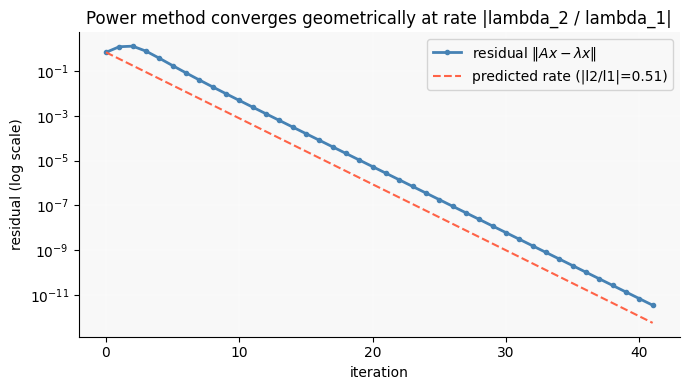

In [14]:
# Convergence curve (log scale): residual should drop geometrically
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(loss_history, color="steelblue", lw=2, marker="o", ms=3,
            label=r"residual $\|Ax-\lambda x\|$")
# predicted rate ~ |lambda2/lambda1|^k
ratio = abs(vals_true[-2] / vals_true[-1])
ax.semilogy(loss_history[0]*ratio**np.arange(len(loss_history)),
            color="tomato", ls="--", label=f"predicted rate (|l2/l1|={ratio:.2f})")
ax.set_xlabel("iteration"); ax.set_ylabel("residual (log scale)")
ax.set_title("Power method converges geometrically at rate |lambda_2 / lambda_1|")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 9 · Deflation — peeling off eigenvectors one at a time

The power method gives only the **top** eigenpair. To get the second, third, ... we use **deflation**: once we've found $(\lambda_1, \mathbf{v}_1)$, subtract its contribution from $A$ so the *next* power method run finds the second.

For a symmetric matrix, deflation is clean. Define:

$$A' = A - \lambda_1\,\mathbf{v}_1\mathbf{v}_1^\top.$$

The term $\mathbf{v}_1\mathbf{v}_1^\top$ is the **outer product** — a rank-1 matrix that projects onto $\mathbf{v}_1$. Subtracting $\lambda_1$ times it does something surgical:

- For $\mathbf{v}_1$ itself: $A'\mathbf{v}_1 = A\mathbf{v}_1 - \lambda_1\mathbf{v}_1(\mathbf{v}_1^\top\mathbf{v}_1) = \lambda_1\mathbf{v}_1 - \lambda_1\mathbf{v}_1 = \mathbf{0}.$ Its eigenvalue is **zeroed out**.
- For any other eigenvector $\mathbf{v}_j$ (orthogonal to $\mathbf{v}_1$, so $\mathbf{v}_1^\top\mathbf{v}_j=0$): $A'\mathbf{v}_j = \lambda_j\mathbf{v}_j$. **Untouched.**

> **Key insight:** Deflation knocks the dominant eigenvalue down to zero while leaving every other eigenpair exactly as it was. So the *new* dominant eigenvalue is the old *second* one — run the power method again and you get $\mathbf{v}_2$. Repeat to extract the full spectrum. This is conceptually how iterative PCA peels off principal components in order.

In [15]:
def eig_by_deflation(A, k=None):
    # Extract top-k eigenpairs of a symmetric matrix via power method + deflation.
    A = A.copy().astype(float)
    n = A.shape[0]
    k = k or n
    eigenvalues, eigenvectors = [], []
    for _ in range(k):
        lam, v, _ = power_method(A, num_iters=200)
        eigenvalues.append(lam)
        eigenvectors.append(v)
        A = A - lam * np.outer(v, v)      # deflate
    return np.array(eigenvalues), np.array(eigenvectors).T

S = np.array([[4.0, 1.0, 0.5],
              [1.0, 3.0, 0.2],
              [0.5, 0.2, 2.0]])
vals_def, vecs_def = eig_by_deflation(S)

vals_true, _ = np.linalg.eigh(S)
print("deflation eigenvalues (desc):", vals_def)
print("true eigenvalues      (desc):", vals_true[::-1])
print("\nmax error:", np.abs(np.sort(vals_def) - vals_true).max())

deflation eigenvalues (desc): [4.7216 2.3983 1.8801]
true eigenvalues      (desc): [4.7216 2.3983 1.8801]

max error: 1.7763568394002505e-15


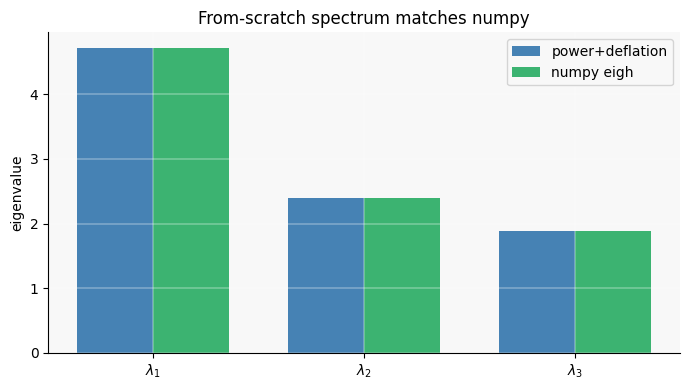

In [16]:
# Visualize the spectrum recovered by our from-scratch pipeline vs ground truth
fig, ax = plt.subplots(figsize=(7, 4))
idx = np.arange(len(vals_def))
ax.bar(idx-0.18, np.sort(vals_def)[::-1], width=0.36, color="steelblue", label="power+deflation")
ax.bar(idx+0.18, vals_true[::-1],         width=0.36, color="mediumseagreen", label="numpy eigh")
ax.set_xticks(idx); ax.set_xticklabels([f"$\\lambda_{i+1}$" for i in idx])
ax.set_ylabel("eigenvalue"); ax.set_title("From-scratch spectrum matches numpy")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 10 · Interactive: watch eigenvalue separation control convergence

The power method's speed is governed entirely by the gap between the top two eigenvalues. Drag the slider to set $\lambda_1$ (with $\lambda_2=1$ fixed) and watch the residual curve: a bigger gap ⇒ steeper drop. If $\lambda_1$ approaches $\lambda_2$, convergence crawls.

*(If `ipywidgets` isn't available, the static fallback below plots three representative cases.)*

In [17]:
try:
    from ipywidgets import interact, FloatSlider

    def demo(lambda1=4.0):
        D = np.diag([lambda1, 1.0, 0.3])     # known eigenvalues
        R = rng.standard_normal((3,3)); Qr,_ = np.linalg.qr(R)
        M = Qr @ D @ Qr.T                    # symmetric with those eigenvalues
        _, _, hist = power_method(M, num_iters=60)
        fig, ax = plt.subplots(figsize=(7,4))
        ax.semilogy(hist, color="steelblue", lw=2, marker="o", ms=3)
        ax.set_title(f"lambda1={lambda1:.1f}, lambda2=1.0  ->  ratio={1.0/lambda1:.2f}")
        ax.set_xlabel("iteration"); ax.set_ylabel("residual (log)")
        ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

    interact(demo, lambda1=FloatSlider(min=1.1, max=8, step=0.1, value=4.0))
except Exception as e:
    print("ipywidgets unavailable, showing static comparison:", e)
    fig, ax = plt.subplots(figsize=(7,4))
    for l1, c in zip([1.2, 2.5, 6.0], ["tomato","darkorange","mediumseagreen"]):
        D = np.diag([l1, 1.0, 0.3])
        Rm = rng.standard_normal((3,3)); Qr,_ = np.linalg.qr(Rm)
        M = Qr @ D @ Qr.T
        _,_,hist = power_method(M, num_iters=60)
        ax.semilogy(hist, color=c, lw=2, label=f"lambda1={l1}, ratio={1/l1:.2f}")
    ax.set_xlabel("iteration"); ax.set_ylabel("residual (log)")
    ax.set_title("Smaller eigenvalue ratio -> faster power-method convergence")
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

interactive(children=(FloatSlider(value=4.0, description='lambda1', max=8.0, min=1.1), Output()), _dom_classes…

---
## 11 · Summary

You've built the entire EVD toolkit from scratch: the definition, the characteristic polynomial, diagonalization, the spectral theorem for symmetric matrices, the geometry of quadratic forms, the Rayleigh-quotient optimization view, whitening, the power method, and deflation.

| Concept | Key Idea |
|---------|----------|
| **Eigenvector / eigenvalue** | $A\mathbf{v}=\lambda\mathbf{v}$: direction left un-rotated by $A$, scaled by $\lambda$ |
| **Characteristic equation** | $\det(A-\lambda I)=0$; eigenvalues are its roots |
| **Trace & determinant** | $\operatorname{tr}(A)=\sum\lambda_i$, $\det(A)=\prod\lambda_i$ (quick-fire favorite) |
| **Diagonalization** | $A=P\Lambda P^{-1}$; makes $A^k=P\Lambda^k P^{-1}$ trivial |
| **Spectral theorem** | Symmetric $A=Q\Lambda Q^\top$: real eigenvalues, orthonormal eigenvectors; use `eigh` |
| **Quadratic form** | $\mathbf{x}^\top A\mathbf{x}$; level sets are ellipses with eigenvectors as axes |
| **Definiteness** | signs of eigenvalues; valid covariance matrix $\iff$ PSD |
| **Rayleigh quotient** | $\frac{\mathbf{x}^\top A\mathbf{x}}{\mathbf{x}^\top\mathbf{x}}\in[\lambda_{\min},\lambda_{\max}]$; max at top eigenvector (= PCA) |
| **Whitening** | $\mathbf{z}=\Lambda^{-1/2}Q^\top(\mathbf{x}-\mu)$ gives $\operatorname{Cov}=I$ |
| **Power method** | iterate $\mathbf{x}\leftarrow A\mathbf{x}/\|A\mathbf{x}\|$; finds top eigenvector; rate $=|\lambda_2/\lambda_1|$ |
| **Deflation** | $A'=A-\lambda_1\mathbf{v}_1\mathbf{v}_1^\top$ zeros the top eigenvalue to expose the next |

> **Final quant interview reminder:** The chain *covariance matrix → symmetric PSD → eigendecomposition → PCA / principal axes of risk → top eigenvector = direction of max variance* is one of the highest-yield stories you can tell. The eigenvalues are the variances along the principal components; their sum (the trace) is the total variance. Be ready to derive the Rayleigh-quotient / Lagrange-multiplier connection on a whiteboard.